# Apparent Facial-Tone Data Bias Audit

## Notebook purpose

This notebook checks whether the real and generated face-image classes contain diverse ranges of **visible facial color and lightness**.

It is a representation audit, meaning that it asks:

> Are different apparent facial tones similarly represented in the real and fake image samples?

The notebook does **not** infer race, ethnicity, ancestry, or a person's permanent skin tone. It measures color values visible in each image.

Those values can be affected by lighting, exposure, shadows, makeup, camera settings, image editing, and generator artifacts.

Gender is also not inferred in this notebook. A face image cannot establish a person's gender identity.

For every audited image, the notebook:

1. Detects the largest face.
2. Defines conservative forehead and cheek sampling regions.
3. Combines the pixels from those regions.
4. Calculates mean and median RGB values.
5. Converts the sampled pixels into CIE Lab color space.
6. Records mean and median apparent facial lightness (`L*`).
7. Reports face-detection success rates.
8. Compares real and fake distributions.
9. Exports one row of audit data per image.

The **mean** is the literal average requested for this audit. The **median** is also recorded because it is less influenced by isolated highlights, shadows, or a small number of incorrectly sampled pixels.

## Important interpretation limit

A lower `L*` value means that the sampled facial regions appear darker in that particular image. A higher `L*` value means that they appear lighter.

This is an image-level measurement, not a demographic identity label.

> **Repository note**
>
> This notebook is a **preliminary apparent-lightness representation audit**, not a race classifier or fairness certification. It measures visible image lightness using detected facial regions and CIE Lab `L*`; lighting, exposure, makeup, editing, cropping, and face-detection failures can affect the measurement. Large face-preview galleries were stripped from this repository copy to keep the project lightweight; the audit code remains reproducible.

## 1. Install the required packages

Kaggle is used to download the dataset. OpenCV provides the face detector,
and scikit-image converts RGB colors into CIE Lab values.

This cell is safe to rerun. Colab may report that some packages are already
installed.

In [1]:
!pip install -q kaggle opencv-python-headless scikit-image

## 2. Imports and audit settings

The audit uses a fixed seed so the same image paths are selected whenever the notebook is restarted and run from the top.

In [2]:
import os
import random
import subprocess
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from skimage.color import rgb2lab
from tqdm.auto import tqdm


SEED = 42

REAL_LABEL = 0
FAKE_LABEL = 1
CLASS_NAMES = ["Real", "Fake"]

AUDIT_TRAIN_SAMPLES_PER_CLASS = 5000
AUDIT_VALID_SAMPLES_PER_CLASS = 1000

DATASET_ROOT = Path("/content/real_vs_fake/real-vs-fake")
AUDIT_OUTPUT_PATH = Path("/content/facial_tone_audit.csv")


def make_balanced_sample(
    real_paths,
    fake_paths,
    samples_per_class,
    seed=SEED,
):
    """
    Select equal numbers of real and fake image paths.

    The same seed produces the same selections and final path order during
    a clean rerun.
    """

    if len(real_paths) < samples_per_class:
        raise ValueError(
            "The real-image class contains fewer images than requested."
        )

    if len(fake_paths) < samples_per_class:
        raise ValueError(
            "The fake-image class contains fewer images than requested."
        )

    path_generator = random.Random(seed)

    selected_real_paths = path_generator.sample(
        list(real_paths),
        samples_per_class,
    )
    selected_fake_paths = path_generator.sample(
        list(fake_paths),
        samples_per_class,
    )

    selected_paths = selected_real_paths + selected_fake_paths

    selected_targets = np.array(
        [REAL_LABEL] * samples_per_class
        + [FAKE_LABEL] * samples_per_class,
        dtype=np.int64,
    )

    shuffle_order = np.random.default_rng(seed).permutation(
        len(selected_paths)
    )

    shuffled_paths = [
        selected_paths[index]
        for index in shuffle_order
    ]
    shuffled_targets = selected_targets[shuffle_order]

    return shuffled_paths, shuffled_targets


print(f"Audit seed: {SEED}")
print(
    "Label convention: "
    f"Real = {REAL_LABEL}, Fake = {FAKE_LABEL}"
)

Audit seed: 42
Label convention: Real = 0, Fake = 1


## 3. Download the dataset from Kaggle

The notebook uses the **140k Real and Fake Faces** dataset.

Store the Kaggle API token in **Colab Secrets** under:

`KAGGLE_API_TOKEN`

The secret is copied only into the temporary Colab runtime. It should not
be written into the notebook or committed to GitHub.

In [3]:
from google.colab import userdata


def download_kaggle_dataset(
    dataset_name="xhlulu/140k-real-and-fake-faces",
    download_directory=Path("/content"),
):
    """Download and unzip the face dataset into the Colab runtime."""

    expected_directories = [
        DATASET_ROOT / "train" / "real",
        DATASET_ROOT / "train" / "fake",
        DATASET_ROOT / "valid" / "real",
        DATASET_ROOT / "valid" / "fake",
        DATASET_ROOT / "test" / "real",
        DATASET_ROOT / "test" / "fake",
    ]

    dataset_is_ready = all(
        directory.exists() and any(directory.iterdir())
        for directory in expected_directories
    )

    if dataset_is_ready:
        print(f"Dataset already found at: {DATASET_ROOT}")
        return

    kaggle_token = userdata.get("KAGGLE_API_TOKEN")

    if not kaggle_token:
        raise ValueError(
            "KAGGLE_API_TOKEN was not found in Colab Secrets."
        )

    kaggle_directory = Path.home() / ".kaggle"
    kaggle_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    token_path = kaggle_directory / "access_token"
    token_path.write_text(kaggle_token)
    token_path.chmod(0o600)

    print(f"Downloading Kaggle dataset: {dataset_name}")

    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            dataset_name,
            "--unzip",
            "-p",
            str(download_directory),
        ],
        check=True,
    )

    print("Dataset download and extraction complete.")


download_kaggle_dataset()

Dataset download and extraction complete.


## 4. Locate and count the dataset images

The dataset contains official training, validation, and test folders.
This audit uses training and validation images. The test folder remains
untouched so it can still be reserved for final model evaluation.

In [4]:
TRAIN_REAL_DIRECTORY = DATASET_ROOT / "train" / "real"
TRAIN_FAKE_DIRECTORY = DATASET_ROOT / "train" / "fake"

VALID_REAL_DIRECTORY = DATASET_ROOT / "valid" / "real"
VALID_FAKE_DIRECTORY = DATASET_ROOT / "valid" / "fake"

TEST_REAL_DIRECTORY = DATASET_ROOT / "test" / "real"
TEST_FAKE_DIRECTORY = DATASET_ROOT / "test" / "fake"


def list_image_paths(directory):
    """Return sorted image paths from one directory."""

    return sorted(
        path
        for path in directory.glob("*")
        if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )


train_real_paths = list_image_paths(TRAIN_REAL_DIRECTORY)
train_fake_paths = list_image_paths(TRAIN_FAKE_DIRECTORY)

valid_real_paths = list_image_paths(VALID_REAL_DIRECTORY)
valid_fake_paths = list_image_paths(VALID_FAKE_DIRECTORY)

test_real_paths = list_image_paths(TEST_REAL_DIRECTORY)
test_fake_paths = list_image_paths(TEST_FAKE_DIRECTORY)


dataset_count_table = pd.DataFrame(
    [
        {
            "Split": "Training",
            "Real": len(train_real_paths),
            "Fake": len(train_fake_paths),
        },
        {
            "Split": "Validation",
            "Real": len(valid_real_paths),
            "Fake": len(valid_fake_paths),
        },
        {
            "Split": "Test",
            "Real": len(test_real_paths),
            "Fake": len(test_fake_paths),
        },
    ]
)

display(dataset_count_table)

if dataset_count_table[["Real", "Fake"]].min().min() == 0:
    raise FileNotFoundError(
        "At least one dataset class folder is empty. "
        "Recheck the dataset download and DATASET_ROOT."
    )

,Split,Real,Fake
0,Training,50000,50000
1,Validation,10000,10000
2,Test,10000,10000


## 5. Select balanced audit samples

An equal number of real and fake images is selected from each audited
split. Balancing the classes makes their distributions easier to compare.

Training and validation paths remain separate.

In [5]:
audit_train_paths, audit_train_targets = make_balanced_sample(
    train_real_paths,
    train_fake_paths,
    samples_per_class=AUDIT_TRAIN_SAMPLES_PER_CLASS,
    seed=SEED,
)

audit_valid_paths, audit_valid_targets = make_balanced_sample(
    valid_real_paths,
    valid_fake_paths,
    samples_per_class=AUDIT_VALID_SAMPLES_PER_CLASS,
    seed=SEED,
)


audit_sample_summary = pd.DataFrame(
    [
        {
            "Split": "Training",
            "Total images": len(audit_train_paths),
            "Real": int(
                (audit_train_targets == REAL_LABEL).sum()
            ),
            "Fake": int(
                (audit_train_targets == FAKE_LABEL).sum()
            ),
        },
        {
            "Split": "Validation",
            "Total images": len(audit_valid_paths),
            "Real": int(
                (audit_valid_targets == REAL_LABEL).sum()
            ),
            "Fake": int(
                (audit_valid_targets == FAKE_LABEL).sum()
            ),
        },
    ]
)

display(audit_sample_summary)

overlapping_paths = set(audit_train_paths).intersection(
    audit_valid_paths
)

assert not overlapping_paths

print("Training and validation audit paths do not overlap.")

,Split,Total images,Real,Fake
0,Training,10000,5000,5000
1,Validation,2000,1000,1000


Training and validation audit paths do not overlap.


# Part II: Detect faces and define sampling regions

## 6. Load the OpenCV face detector

Code block loads pre-trained OpenCV face detector, checks for successful loading, and raises error if not.

In [6]:
FACE_CASCADE_PATH = (
    cv2.data.haarcascades
    + "haarcascade_frontalface_default.xml"
)

face_detector = cv2.CascadeClassifier(
    FACE_CASCADE_PATH
)

if face_detector.empty():
    raise RuntimeError(
        "The OpenCV face detector could not be loaded."
    )

print("OpenCV face detector loaded successfully.")

OpenCV face detector loaded successfully.


## 7. Face detection and facial sampling regions

This code block defines two facial analysis functions. The first, **find_largest_face,** takes an RGB image, converts it to grayscale, and uses OpenCV’s face detector to find faces.

If no faces are found, it returns None. Otherwise, it identifies the largest face by area and returns its coordinates.

The second, **create_facial_sampling_regions**, takes face coordinates and image shape. It includes a helper function, **make_region**, that calculates sub-region coordinates (forehead, cheeks) using proportional values. It clips these coordinates to ensure they stay within the image bounds.

Finally, it returns a dictionary with ‘forehead’, ‘left_cheek’, and ‘right_cheek’ region coordinates.

In [7]:
def find_largest_face(rgb_image):
    """
    Detect and return the largest face in an RGB image.

    Returns
    -------
    tuple or None
        Face coordinates as:
            x, y, width, height

        None is returned when no face is detected.
    """

    grayscale_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2GRAY,
    )

    detected_faces = face_detector.detectMultiScale(
        grayscale_image,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(64, 64),
    )

    if len(detected_faces) == 0:
        return None

    largest_face = max(
        detected_faces,
        key=lambda face: face[2] * face[3],
    )

    x, y, width, height = largest_face

    return (
        int(x),
        int(y),
        int(width),
        int(height),
    )


def create_facial_sampling_regions(
    face_box,
    image_shape,
):
    """
    Create forehead and cheek regions within a detected face.

    Coordinates are clipped so they remain inside the image.
    """

    face_x, face_y, face_width, face_height = face_box

    image_height, image_width = image_shape[:2]

    def make_region(
        horizontal_start,
        vertical_start,
        horizontal_end,
        vertical_end,
    ):
        region_x1 = int(
            face_x + horizontal_start * face_width
        )
        region_y1 = int(
            face_y + vertical_start * face_height
        )
        region_x2 = int(
            face_x + horizontal_end * face_width
        )
        region_y2 = int(
            face_y + vertical_end * face_height
        )

        region_x1 = max(
            0,
            min(region_x1, image_width),
        )
        region_x2 = max(
            0,
            min(region_x2, image_width),
        )
        region_y1 = max(
            0,
            min(region_y1, image_height),
        )
        region_y2 = max(
            0,
            min(region_y2, image_height),
        )

        return (
            region_x1,
            region_y1,
            region_x2,
            region_y2,
        )

    return {
        "forehead": make_region(
            horizontal_start=0.36,
            vertical_start=0.22,
            horizontal_end=0.64,
            vertical_end=0.34,
        ),
        "left_cheek": make_region(
            horizontal_start=0.18,
            vertical_start=0.50,
            horizontal_end=0.38,
            vertical_end=0.68,
        ),
        "right_cheek": make_region(
            horizontal_start=0.62,
            vertical_start=0.50,
            horizontal_end=0.82,
            vertical_end=0.68,
        ),
    }

## 8. Visually inspect the sampling regions

Quality-control step.

Review several real and fake images and check that the rectangles mostly
cover visible forehead and cheek skin. They should avoid hair, eyes,
eyebrows, lips, clothing, and background whenever possible.

The function displays one figure at a time so each image can be inspected
carefully.

In [ ]:
def show_facial_sampling_regions(
    image_paths,
    sample_count=20,
    seed=SEED,
):
    """Display seeded image examples with audit regions overlaid."""

    sample_generator = random.Random(seed)

    selected_paths = sample_generator.sample(
        list(image_paths),
        min(sample_count, len(image_paths)),
    )

    for image_path in selected_paths:
        with Image.open(image_path) as image:
            rgb_image = np.asarray(
                image.convert("RGB"),
                dtype=np.uint8,
            )

        face_box = find_largest_face(rgb_image)

        plt.figure(figsize=(5, 5))
        plt.imshow(rgb_image)
        plt.axis("off")

        if face_box is None:
            plt.title(
                f"No face detected: {Path(image_path).name}"
            )
            plt.show()
            continue

        face_x, face_y, face_width, face_height = face_box

        face_rectangle = plt.Rectangle(
            (face_x, face_y),
            face_width,
            face_height,
            fill=False,
            linewidth=2,
        )

        plt.gca().add_patch(face_rectangle)

        sampling_regions = create_facial_sampling_regions(
            face_box=face_box,
            image_shape=rgb_image.shape,
        )

        for region_name, coordinates in sampling_regions.items():
            x1, y1, x2, y2 = coordinates

            region_rectangle = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
            )

            plt.gca().add_patch(region_rectangle)

            plt.text(
                x1,
                y1,
                region_name,
                fontsize=8,
                backgroundcolor="white",
            )

        plt.title(Path(image_path).name)
        plt.show()


print("Real-image examples:")
show_facial_sampling_regions(
    train_real_paths,
    sample_count=20,
    seed=SEED,
)

print("Fake-image examples:")
show_facial_sampling_regions(
    train_fake_paths,
    sample_count=20,
    seed=SEED,
)

# Part III: Measure apparent facial tone

## 9. Calculate per-image color and lightness values

CIE Lab separates color into:

- `L*`: apparent lightness;
- `a*`: green-to-red color dimension;
- `b*`: blue-to-yellow color dimension.

The main audit plots use mean `L*`, which is the average visible lightness of all sampled forehead and cheek pixels.

Median values are retained as a robustness check.

In [20]:
def estimate_apparent_facial_tone(image_path):
    """
    Estimate visible facial color and lightness for one image.

    Returns
    -------
    dict or None
        Measurements are returned when a face and usable facial
        regions are found. Otherwise, None is returned.
    """

    try:
        with Image.open(image_path) as image:
            rgb_image = np.asarray(
                image.convert("RGB"),
                dtype=np.uint8,
            )
    except (OSError, ValueError):
        return None

    face_box = find_largest_face(rgb_image)

    if face_box is None:
        return None

    sampling_regions = create_facial_sampling_regions(
        face_box=face_box,
        image_shape=rgb_image.shape,
    )

    sampled_pixel_groups = []

    for region_coordinates in sampling_regions.values():
        x1, y1, x2, y2 = region_coordinates

        region_pixels = rgb_image[y1:y2, x1:x2]

        if region_pixels.size == 0:
            continue

        sampled_pixel_groups.append(
            region_pixels.reshape(-1, 3)
        )

    if not sampled_pixel_groups:
        return None

    sampled_rgb_pixels = np.concatenate(
        sampled_pixel_groups,
        axis=0,
    )

    mean_rgb = sampled_rgb_pixels.mean(axis=0)

    median_rgb = np.median(
        sampled_rgb_pixels,
        axis=0,
    )

    sampled_rgb_float = (
        sampled_rgb_pixels.astype(np.float32) / 255.0
    )

    sampled_lab_pixels = rgb2lab(
        sampled_rgb_float.reshape(-1, 1, 3)
    ).reshape(-1, 3)

    mean_lab = sampled_lab_pixels.mean(axis=0)

    median_lab = np.median(
        sampled_lab_pixels,
        axis=0,
    )

    median_rgb_integer = np.clip(
        np.round(median_rgb),
        0,
        255,
    ).astype(int)

    tone_hex = (
        f"#{median_rgb_integer[0]:02x}"
        f"{median_rgb_integer[1]:02x}"
        f"{median_rgb_integer[2]:02x}"
    )

    face_x, face_y, face_width, face_height = face_box

    return {
        "face_x": face_x,
        "face_y": face_y,
        "face_width": face_width,
        "face_height": face_height,
        "sampled_pixel_count": int(
            len(sampled_rgb_pixels)
        ),
        "mean_red": float(mean_rgb[0]),
        "mean_green": float(mean_rgb[1]),
        "mean_blue": float(mean_rgb[2]),
        "median_red": float(median_rgb[0]),
        "median_green": float(median_rgb[1]),
        "median_blue": float(median_rgb[2]),
        "mean_lab_l": float(mean_lab[0]),
        "mean_lab_a": float(mean_lab[1]),
        "mean_lab_b": float(mean_lab[2]),
        "median_lab_l": float(median_lab[0]),
        "median_lab_a": float(median_lab[1]),
        "median_lab_b": float(median_lab[2]),
        "tone_hex": tone_hex,
    }

## 10. Test the measurement on one image

Review the returned values before processing the full sample.

`mean_lab_l` is the primary average facial-lightness measurement.

In [21]:
example_tone_result = estimate_apparent_facial_tone(
    audit_valid_paths[0]
)

display(example_tone_result)

{'face_x': 58,
 'face_y': 74,
 'face_width': 145,
 'face_height': 145,
 'sampled_pixel_count': 2228,
 'mean_red': 131.99057450628365,
 'mean_green': 80.98159784560144,
 'mean_blue': 70.47441651705566,
 'median_red': 155.0,
 'median_green': 94.0,
 'median_blue': 81.0,
 'mean_lab_l': 39.31770706176758,
 'mean_lab_a': 19.784170150756836,
 'mean_lab_b': 14.982681274414062,
 'median_lab_l': 46.257606506347656,
 'median_lab_a': 22.64133071899414,
 'median_lab_b': 15.968572616577148,
 'tone_hex': '#9b5e51'}

## 11. Process the full audit sample

One output row is created for every selected image, including images for
which face detection fails.

Failed detections are maintained as the failure rate may differ between the real and fake classes.

In [22]:
def build_facial_tone_table(
    image_paths,
    numeric_targets,
    split_name,
):
    """Calculate facial-tone measurements for an image sample."""

    if len(image_paths) != len(numeric_targets):
        raise ValueError(
            "Image paths and targets must have equal lengths."
        )

    result_rows = []

    image_and_target_pairs = zip(
        image_paths,
        numeric_targets,
    )

    for image_path, numeric_target in tqdm(
        image_and_target_pairs,
        total=len(image_paths),
        desc=f"Analyzing {split_name} images",
    ):
        tone_result = estimate_apparent_facial_tone(
            image_path
        )

        result_row = {
            "image_path": str(image_path),
            "split": split_name,
            "numeric_target": int(numeric_target),
            "class_name": CLASS_NAMES[int(numeric_target)],
            "face_detected": tone_result is not None,
        }

        if tone_result is not None:
            result_row.update(tone_result)

        result_rows.append(result_row)

    return pd.DataFrame(result_rows)


train_facial_tone_table = build_facial_tone_table(
    image_paths=audit_train_paths,
    numeric_targets=audit_train_targets,
    split_name="Training",
)

valid_facial_tone_table = build_facial_tone_table(
    image_paths=audit_valid_paths,
    numeric_targets=audit_valid_targets,
    split_name="Validation",
)

facial_tone_table = pd.concat(
    [
        train_facial_tone_table,
        valid_facial_tone_table,
    ],
    ignore_index=True,
)

display(facial_tone_table.head())

Analyzing Training images:   0%|          | 0/10000 [00:00<?, ?it/s]

Analyzing Validation images:   0%|          | 0/2000 [00:00<?, ?it/s]

,image_path,split,numeric_target,class_name,face_detected,face_x,face_y,face_width,face_height,sampled_pixel_count,...,median_red,median_green,median_blue,mean_lab_l,mean_lab_a,mean_lab_b,median_lab_l,median_lab_a,median_lab_b,tone_hex
0,/content/real_vs_fake/real-vs-fake/train/fake/...,Training,1,Fake,True,41.0,49.0,178.0,178.0,3269.0,...,242.0,163.0,114.0,73.577728,21.452900,34.933189,73.980095,22.845627,36.317814,#f2a372
1,/content/real_vs_fake/real-vs-fake/train/fake/...,Training,1,Fake,True,37.0,54.0,180.0,180.0,3426.0,...,147.0,98.0,76.0,48.382607,16.459179,19.404478,46.506714,16.447708,19.514948,#93624c
2,/content/real_vs_fake/real-vs-fake/train/real/...,Training,0,Real,True,39.0,56.0,171.0,171.0,3116.0,...,248.0,199.0,175.0,80.692947,13.421682,17.515211,83.887581,13.935060,18.100536,#f8c7af
3,/content/real_vs_fake/real-vs-fake/train/fake/...,Training,1,Fake,True,28.0,51.0,190.0,190.0,3803.0,...,182.0,137.0,130.0,58.145382,13.034680,11.514638,60.943405,14.985353,12.087703,#b68982
4,/content/real_vs_fake/real-vs-fake/train/real/...,Training,0,Real,True,39.0,48.0,183.0,183.0,3586.0,...,172.0,126.0,99.0,54.432346,14.601955,21.072170,56.658592,15.106932,21.398294,#ac7e63


# Part IV: Audit the measurement process

## 12. Face-detection success rates

A facial-tone value can only be calculated when the face detector succeeds.

Detection percentages should be reviewed by both split and class. A lower
detection rate for one class means that the final tone distribution may
not represent that class equally well.

In [12]:
detection_summary = (
    facial_tone_table
    .groupby(
        ["split", "class_name"],
        observed=True,
    )["face_detected"]
    .agg(
        total_images="count",
        detected_faces="sum",
        detection_rate="mean",
    )
    .reset_index()
)

detection_summary["detection_percentage"] = (
    detection_summary["detection_rate"] * 100
)

display(
    detection_summary[
        [
            "split",
            "class_name",
            "total_images",
            "detected_faces",
            "detection_percentage",
        ]
    ].round(2)
)

,split,class_name,total_images,detected_faces,detection_percentage
0,Training,Fake,5000,4966,99.32
1,Training,Real,5000,4712,94.24
2,Validation,Fake,1000,992,99.20
3,Validation,Real,1000,959,95.90


## 13. Summary statistics

These values describe the measured images only. Detection failures are
reported separately above.

The table includes both the average (`mean_lab_l`) and robust median
(`median_lab_l`) apparent facial-lightness measurements.

In [13]:
measured_tone_data = facial_tone_table.dropna(
    subset=["mean_lab_l"]
).copy()

tone_summary = (
    measured_tone_data
    .groupby(
        ["split", "class_name"],
        observed=True,
    )
    .agg(
        measured_images=("mean_lab_l", "count"),
        average_lightness=("mean_lab_l", "mean"),
        lightness_standard_deviation=(
            "mean_lab_l",
            "std",
        ),
        median_of_average_lightness=(
            "mean_lab_l",
            "median",
        ),
        average_robust_median=(
            "median_lab_l",
            "mean",
        ),
    )
    .reset_index()
)

display(tone_summary.round(3))

,split,class_name,measured_images,average_lightness,lightness_standard_deviation,median_of_average_lightness,average_robust_median
0,Training,Fake,4966,61.837,10.587,62.712,63.676
1,Training,Real,4712,61.249,11.935,61.994,62.967
2,Validation,Fake,992,62.007,10.493,62.864,63.896
3,Validation,Real,959,61.341,11.932,62.036,63.001


# Part V: Plot the apparent facial-tone distributions

## 14. Plot average apparent facial lightness

Each image contributes one `mean_lab_l` value.

The real and fake histograms use the same bin boundaries within each
split so their shapes can be compared directly.

Look for:

- similar or different ranges;
- one class concentrated in a narrower range;
- gaps or thinly represented areas;
- a shift toward lower or higher visible lightness.

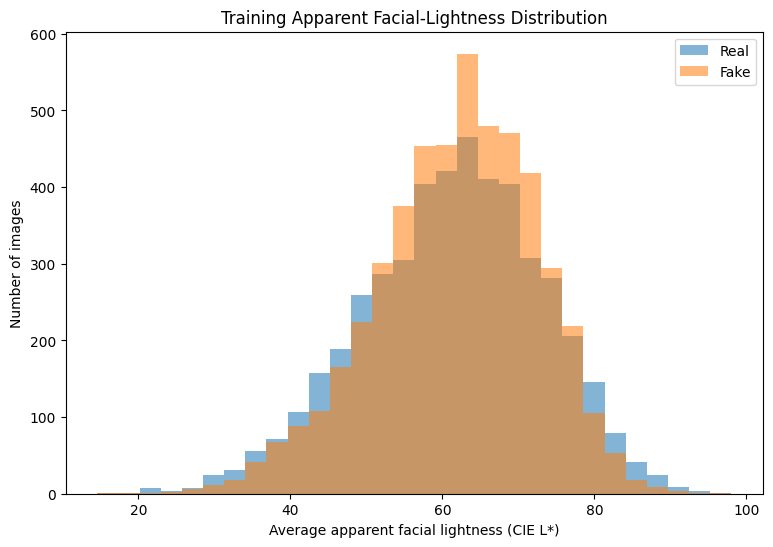

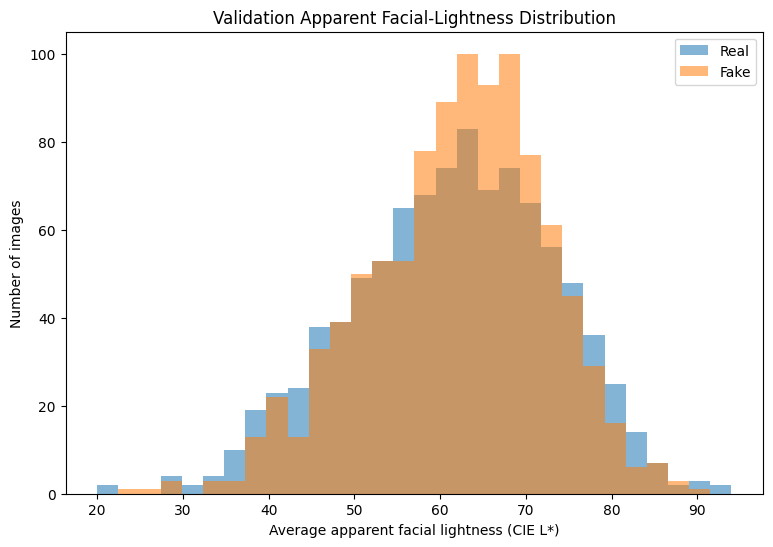

In [14]:
def plot_lightness_distribution(
    audit_table,
    split_name,
    measurement_column="mean_lab_l",
):
    """Plot real and fake lightness histograms for one split."""

    split_data = audit_table.loc[
        audit_table["split"] == split_name
    ].dropna(
        subset=[measurement_column]
    )

    if split_data.empty:
        print(
            f"No measured facial-tone data for {split_name}."
        )
        return

    minimum_value = split_data[measurement_column].min()
    maximum_value = split_data[measurement_column].max()

    shared_bins = np.linspace(
        minimum_value,
        maximum_value,
        31,
    )

    plt.figure(figsize=(9, 6))

    for class_value, class_name in [
        (REAL_LABEL, "Real"),
        (FAKE_LABEL, "Fake"),
    ]:
        class_values = split_data.loc[
            split_data["numeric_target"] == class_value,
            measurement_column,
        ]

        plt.hist(
            class_values,
            bins=shared_bins,
            alpha=0.55,
            label=class_name,
        )

    plt.xlabel(
        "Average apparent facial lightness (CIE L*)"
    )
    plt.ylabel("Number of images")
    plt.title(
        f"{split_name} Apparent Facial-Lightness Distribution"
    )
    plt.legend()
    plt.show()


plot_lightness_distribution(
    facial_tone_table,
    split_name="Training",
)

plot_lightness_distribution(
    facial_tone_table,
    split_name="Validation",
)

## 15. Median-based sensitivity check

The median plot answers the same question using a measurement that is less
affected by isolated bright highlights or dark shadows.

Similar mean and median distribution shapes increase confidence that a
small number of extreme pixels are not driving the result.

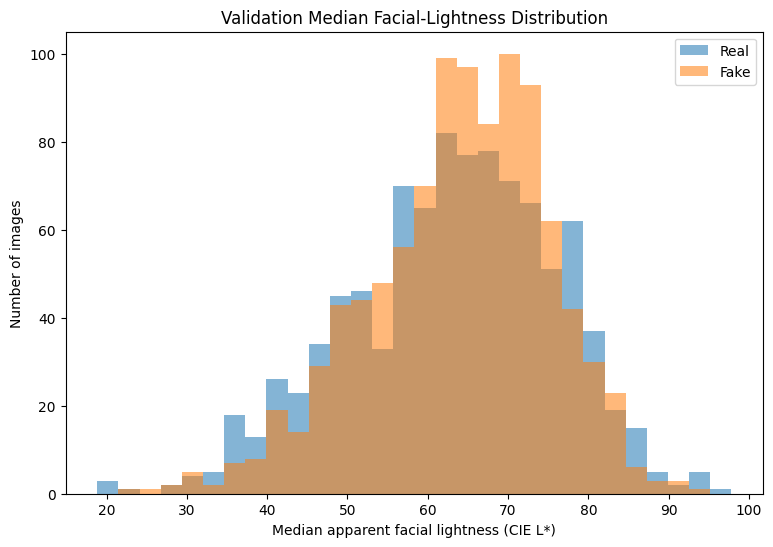

In [15]:
def plot_median_lightness_distribution(
    audit_table,
    split_name,
):
    """Plot median apparent facial-lightness distributions."""

    split_data = audit_table.loc[
        audit_table["split"] == split_name
    ].dropna(
        subset=["median_lab_l"]
    )

    if split_data.empty:
        print(
            f"No measured facial-tone data for {split_name}."
        )
        return

    minimum_value = split_data["median_lab_l"].min()
    maximum_value = split_data["median_lab_l"].max()

    shared_bins = np.linspace(
        minimum_value,
        maximum_value,
        31,
    )

    plt.figure(figsize=(9, 6))

    for class_value, class_name in [
        (REAL_LABEL, "Real"),
        (FAKE_LABEL, "Fake"),
    ]:
        class_values = split_data.loc[
            split_data["numeric_target"] == class_value,
            "median_lab_l",
        ]

        plt.hist(
            class_values,
            bins=shared_bins,
            alpha=0.55,
            label=class_name,
        )

    plt.xlabel(
        "Median apparent facial lightness (CIE L*)"
    )
    plt.ylabel("Number of images")
    plt.title(
        f"{split_name} Median Facial-Lightness Distribution"
    )
    plt.legend()
    plt.show()


plot_median_lightness_distribution(
    facial_tone_table,
    split_name="Validation",
)

## 16. Plot estimated facial-color spectrum strips

Each vertical line represents the median sampled RGB color from one image.

Images are ordered by average `L*` from lower to higher apparent
lightness. The strip is a visualization of measured image colors, not a
demographic scale.

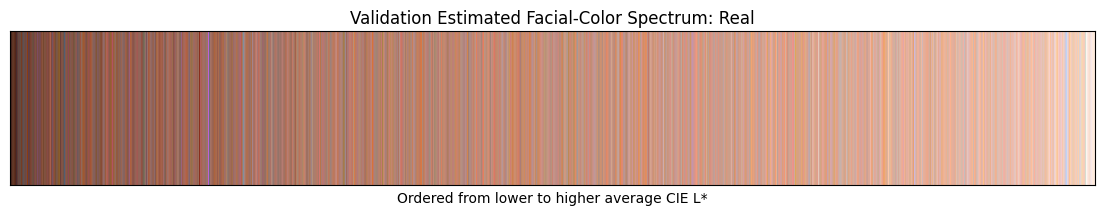

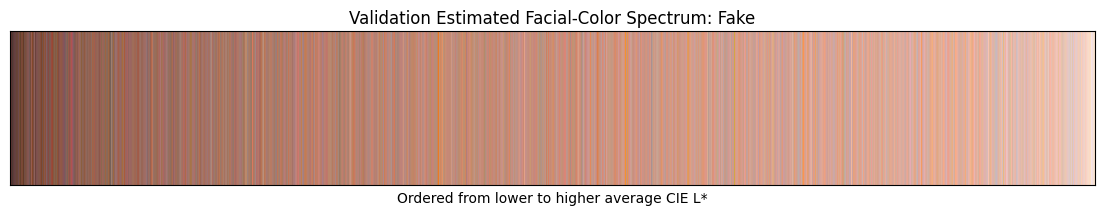

In [16]:
def plot_facial_color_strip(
    audit_table,
    split_name,
    class_value,
    class_name,
):
    """Plot measured median RGB colors ordered by mean L*."""

    class_data = audit_table.loc[
        (
            audit_table["split"] == split_name
        )
        & (
            audit_table["numeric_target"] == class_value
        )
    ].dropna(
        subset=[
            "mean_lab_l",
            "median_red",
            "median_green",
            "median_blue",
        ]
    ).sort_values(
        "mean_lab_l"
    )

    if class_data.empty:
        print(
            f"No measured colors for {split_name} {class_name}."
        )
        return

    color_values = (
        class_data[
            [
                "median_red",
                "median_green",
                "median_blue",
            ]
        ]
        .to_numpy()
        .round()
        .clip(0, 255)
        .astype(np.uint8)
    )

    color_strip = np.repeat(
        color_values[np.newaxis, :, :],
        repeats=40,
        axis=0,
    )

    plt.figure(figsize=(14, 2))
    plt.imshow(
        color_strip,
        aspect="auto",
    )
    plt.yticks([])
    plt.xticks([])
    plt.xlabel(
        "Ordered from lower to higher average CIE L*"
    )
    plt.title(
        f"{split_name} Estimated Facial-Color Spectrum: "
        f"{class_name}"
    )
    plt.show()


plot_facial_color_strip(
    facial_tone_table,
    split_name="Validation",
    class_value=REAL_LABEL,
    class_name="Real",
)

plot_facial_color_strip(
    facial_tone_table,
    split_name="Validation",
    class_value=FAKE_LABEL,
    class_name="Fake",
)

## 17. Compare representation across relative lightness bands

This optional view divides the measured validation images into five
data-relative `L*` bands.

The bands are **not** races, ethnicities, or official skin-tone
categories. They only divide this audit sample from lower to higher
measured apparent lightness.

Each class is converted to percentages so differences are not caused by
class sample size.

class_name,Fake,Real
relative_lightness_band,,
Band 1: lower L*,18.04,22.11
Band 2,19.76,20.23
Band 3,21.57,18.35
Band 4,22.08,17.83
Band 5: higher L*,18.55,21.48


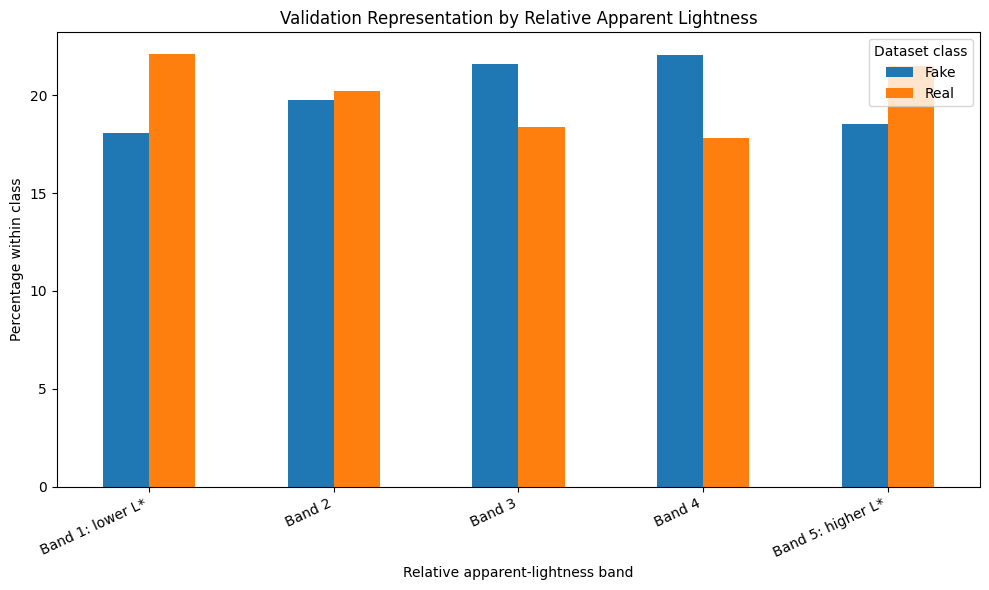

In [17]:
validation_tone_data = measured_tone_data.loc[
    measured_tone_data["split"] == "Validation"
].copy()

lightness_band_labels = [
    "Band 1: lower L*",
    "Band 2",
    "Band 3",
    "Band 4",
    "Band 5: higher L*",
]

validation_tone_data["relative_lightness_band"] = pd.qcut(
    validation_tone_data["mean_lab_l"],
    q=5,
    labels=lightness_band_labels,
    duplicates="drop",
)

band_counts = (
    validation_tone_data
    .groupby(
        ["class_name", "relative_lightness_band"],
        observed=True,
    )
    .size()
    .rename("image_count")
    .reset_index()
)

band_counts["class_percentage"] = (
    band_counts["image_count"]
    / band_counts.groupby("class_name")[
        "image_count"
    ].transform("sum")
    * 100
)

band_percentage_table = band_counts.pivot(
    index="relative_lightness_band",
    columns="class_name",
    values="class_percentage",
).fillna(0)

display(band_percentage_table.round(2))

band_percentage_table.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.xlabel("Relative apparent-lightness band")
plt.ylabel("Percentage within class")
plt.title(
    "Validation Representation by Relative Apparent Lightness"
)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Dataset class")
plt.tight_layout()
plt.show()

# Part VI: Save the audit data

## 18. Export one row per image

The CSV can later be merged with model predictions using `image_path`.

That later performance audit can calculate false-positive and
false-negative rates across apparent-lightness ranges without rerunning
the face-color measurement.

In [18]:
facial_tone_table.to_csv(
    AUDIT_OUTPUT_PATH,
    index=False,
)

print(
    "Saved facial-tone audit data to: "
    f"{AUDIT_OUTPUT_PATH}"
)

print(
    "Rows saved: "
    f"{len(facial_tone_table):,}"
)

Saved facial-tone audit data to: /content/facial_tone_audit.csv
Rows saved: 12,000


###2D Color Gamut Analysis ($a^*$ vs $b^*$)

While the primary audit focuses on apparent lightness ($L^*$), this section expands the investigation into the chromatic dimensions of the CIE $L^*a^*b^*$ color space.

By plotting the $a^*$ (green-to-red) axis against the $b^*$ (blue-to-yellow) axis, the audit shifts from measuring how light or dark the faces are to assessing the actual color distributions and balance between real and synthetic cohorts.

**Color Gamut & Variance:** It maps out the full boundary of color saturation present in the faces. If the "Fake" cluster is noticeably tighter or localized compared to the "Real" cluster, it reveals that the GAN/diffusion generator is operating within a constrained, less diverse color space.

**Color-Shifting Artifacts:** Synthetic generations often leave telltale digital signatures—such as systemic undertones or color cast biases (e.g., pulling heavily towards orange/red or showing an unnatural lack of green tones). This 2D space makes those shifts immediately visible as asymmetric cluster offsets.

**Density Overlap:** Utilizing a semi-transparent scatter plot (alpha=0.3) allows us to see where the core visual weight of both classes sits, revealing whether the generator prioritizes a specific "average" complexion archetype relative to real-world data.

**Statistical Baseline Features**

**Axes Breakdown:** * The $a^*$ axis tracks shifts from green (negative values) to red (positive values).The $b^*$ axis tracks shifts from blue (negative values) to yellow (positive values).

**Reference Lines:** Gray dashed lines at $a^* = 0$ and $b^* = 0$ mark the true neutral grayscale origin point, providing an anchor to judge absolute color warmth and saturation levels.

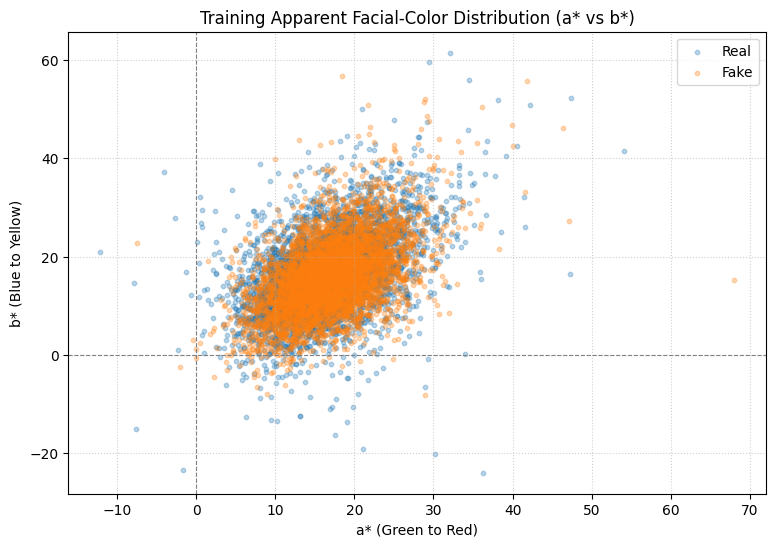

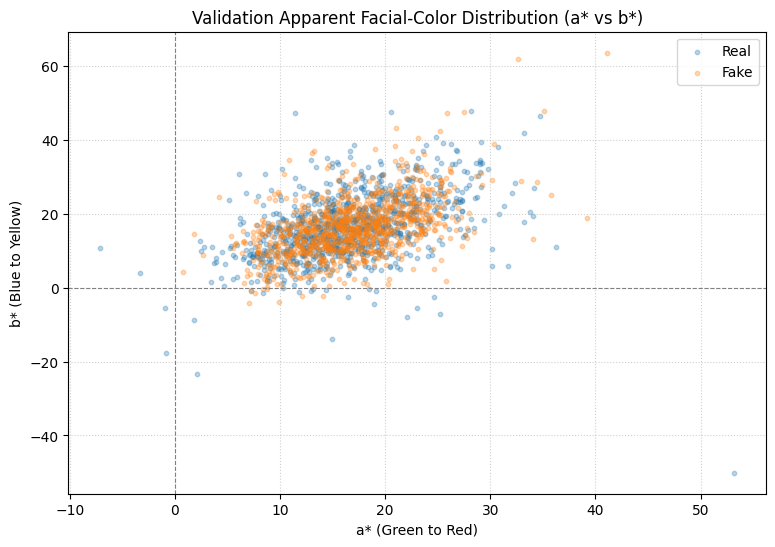

In [23]:
def plot_ab_scatter_distribution(
    audit_table,
    split_name,
):
    """Plot real and fake a* and b* scatter plots for one split."""

    split_data = audit_table.loc[
        audit_table["split"] == split_name
    ].dropna(
        subset=["mean_lab_a", "mean_lab_b"]
    )

    if split_data.empty:
        print(
            f"No measured facial-tone data for {split_name} for a*b* plot."
        )
        return

    plt.figure(figsize=(9, 6))

    for class_value, class_name in [
        (REAL_LABEL, "Real"),
        (FAKE_LABEL, "Fake"),
    ]:
        class_values = split_data.loc[
            split_data["numeric_target"] == class_value
        ]

        plt.scatter(
            class_values["mean_lab_a"],
            class_values["mean_lab_b"],
            alpha=0.3,
            s=10,
            label=class_name,
        )

    plt.xlabel("a* (Green to Red)")
    plt.ylabel("b* (Blue to Yellow)")
    plt.title(
        f"{split_name} Apparent Facial-Color Distribution (a* vs b*)"
    )
    plt.legend()
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


plot_ab_scatter_distribution(
    facial_tone_table,
    split_name="Training",
)

plot_ab_scatter_distribution(
    facial_tone_table,
    split_name="Validation",
)


#Disclaimer:
> Apparent facial tone was estimated from forehead and cheek regions and
> summarized using CIE Lab lightness. These measurements describe visible
> image characteristics and may be affected by lighting, exposure, makeup,
> image processing, and face-detection errors. They should not be
> interpreted as racial, ethnic, or gender identities.

## References and technical documentation

- OpenCV. *Cascade Classifier: Face Detection.*
  https://docs.opencv.org/4.x/db/d28/tutorial_cascade_classifier.html
- scikit-image. *Color space conversions.*
  https://scikit-image.org/docs/stable/api/skimage.color.html
- Matplotlib. *Histogram documentation.*
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
- Kaggle. *140k Real and Fake Faces.*
  https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces